In [1]:
import mynn
from draw_tools.plot import plot
import numpy as np
from struct import unpack
import pickle
import gzip
import matplotlib.pyplot as plt

# fixed seed for experiment
np.random.seed(309)

train_images_path = r'.\dataset\MNIST\train-images-idx3-ubyte.gz'
train_labels_path = r'.\dataset\MNIST\train-labels-idx1-ubyte.gz'

with gzip.open(train_images_path, 'rb') as f:
        magic, num, rows, cols = unpack('>4I', f.read(16))
        train_imgs=np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28*28)
    
with gzip.open(train_labels_path, 'rb') as f:
        magic, num = unpack('>2I', f.read(8))
        train_labs = np.frombuffer(f.read(), dtype=np.uint8)


# choose 10000 samples from train set as validation set.
idx = np.random.permutation(np.arange(num))
# save the index.
with open('idx.pickle', 'wb') as f:
        pickle.dump(idx, f)
train_imgs = train_imgs[idx]
train_labs = train_labs[idx]
valid_imgs = train_imgs[:10000]
valid_labs = train_labs[:10000]
train_imgs = train_imgs[10000:]
train_labs = train_labs[10000:]

# normalize from [0, 255] to [0, 1]
train_imgs = train_imgs / train_imgs.max()
valid_imgs = valid_imgs / valid_imgs.max()



#### Show examples

Example 1, Label: 7


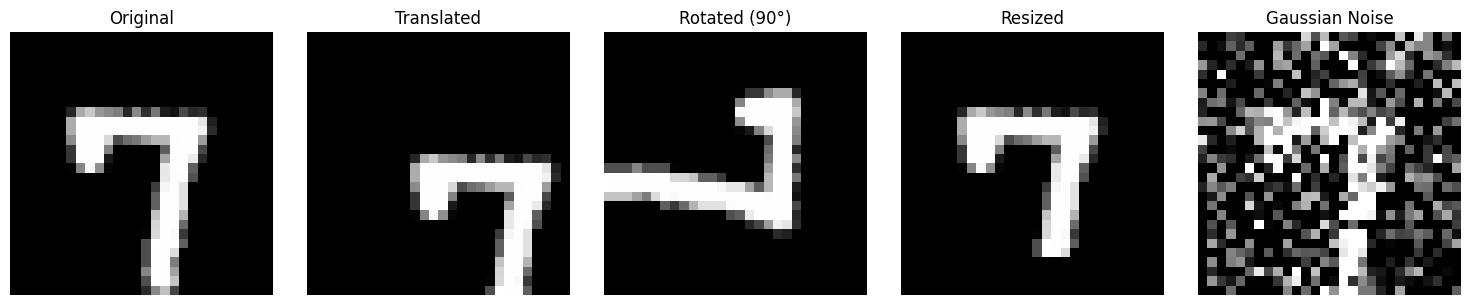

Example 2, Label: 7


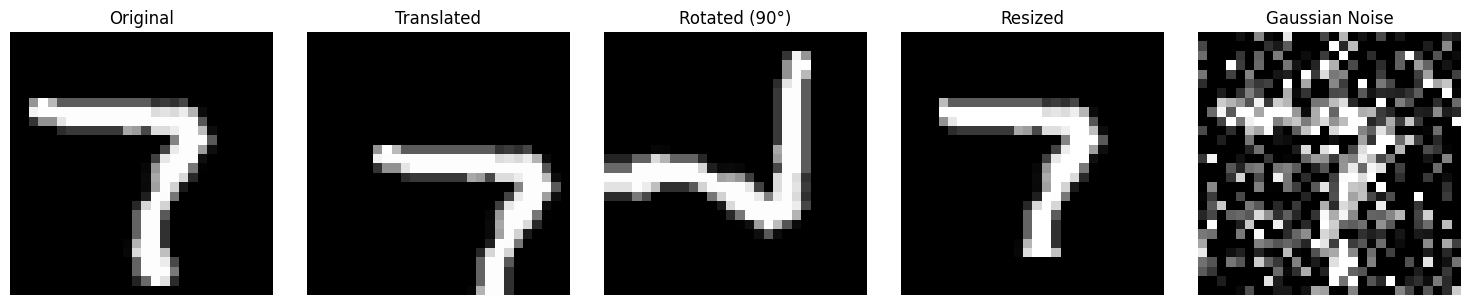

Example 3, Label: 7


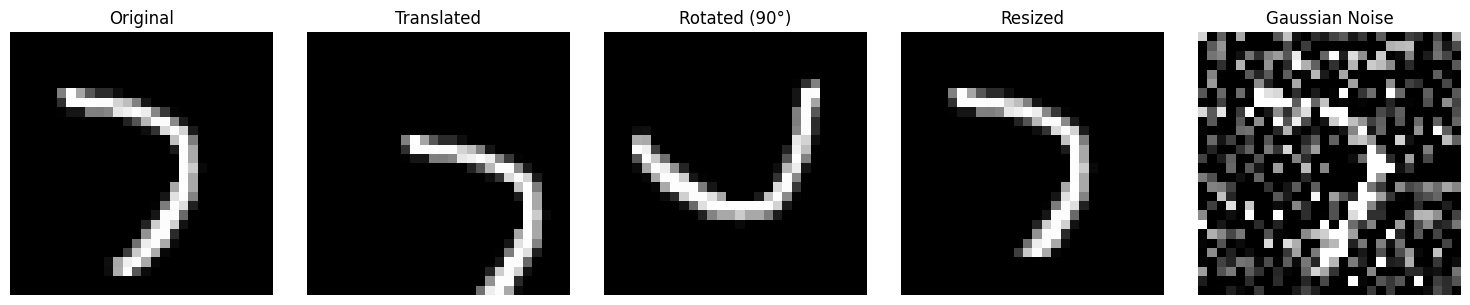

Example 4, Label: 7


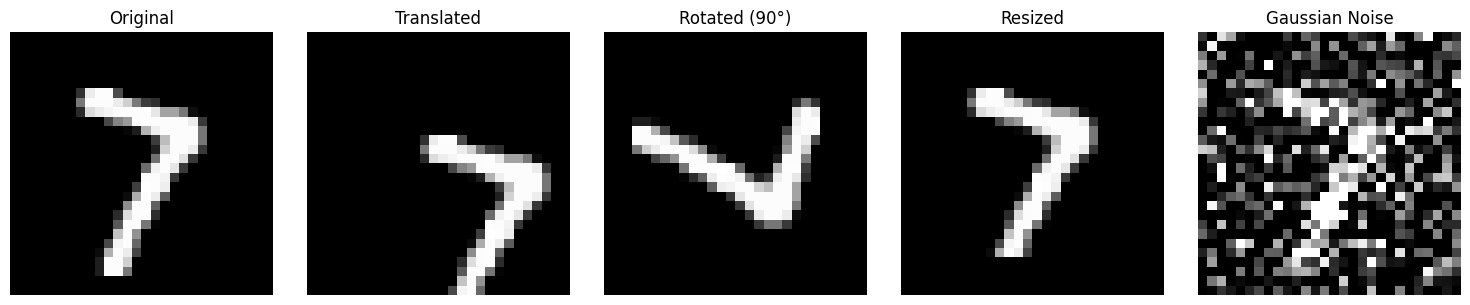

Example 5, Label: 7


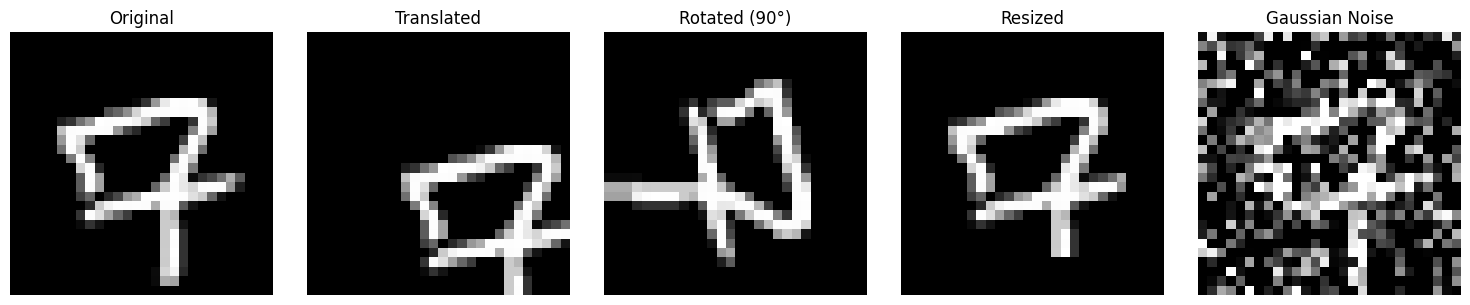

Example 6, Label: 7


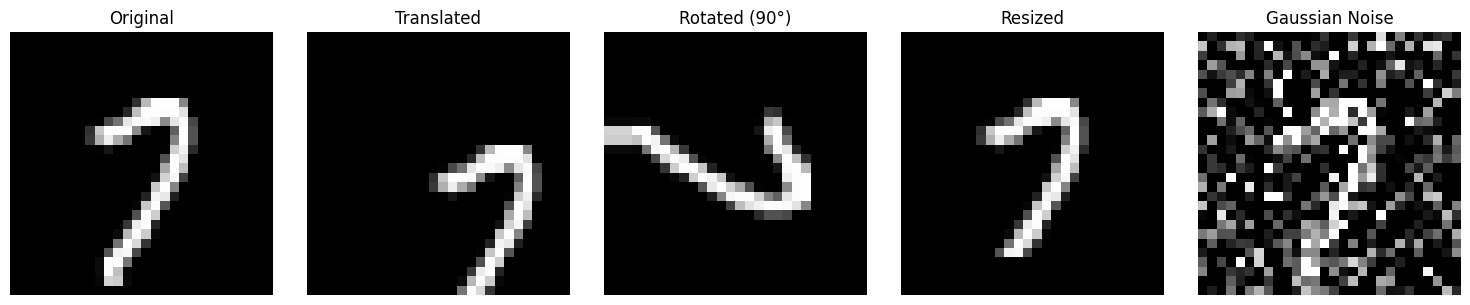

Example 7, Label: 8


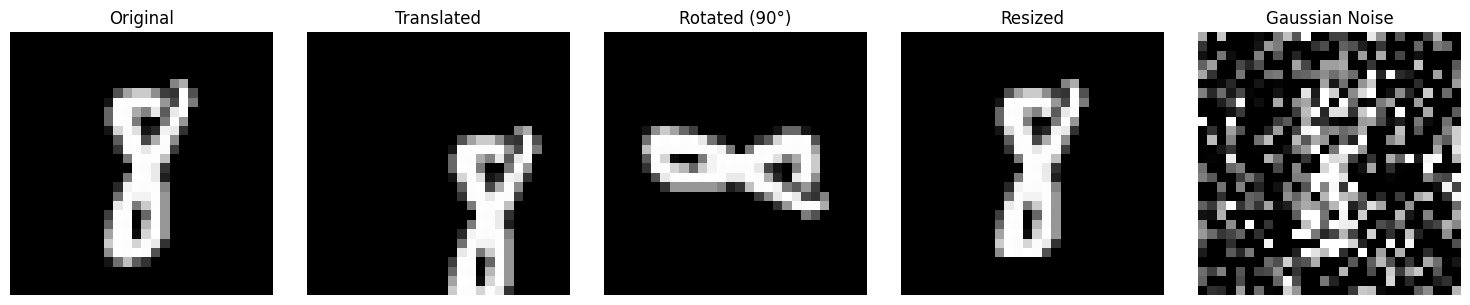

Example 8, Label: 3


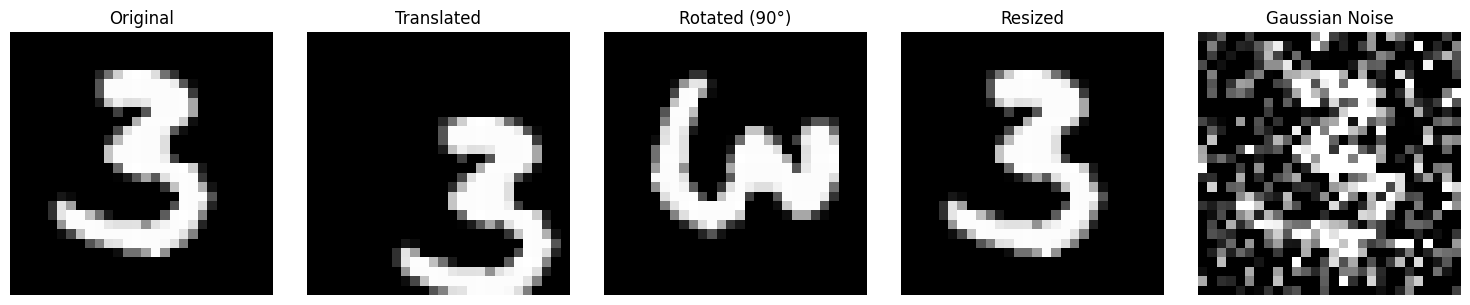

Example 9, Label: 0


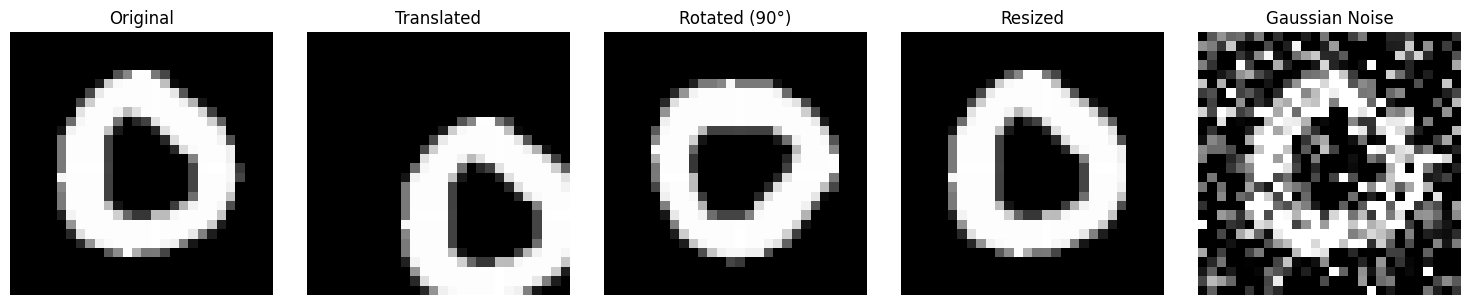

Example 10, Label: 4


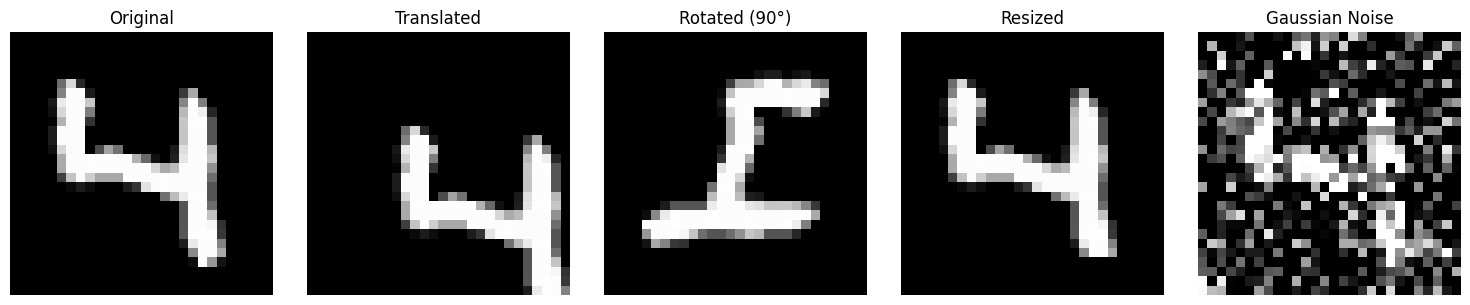

In [6]:
augmentor = mynn.runner.DataAugmentation(image_shape=(28, 28), resize_shape=(20, 20), max_rotation=90, noise_std=0.5)
for i in range(10):
    print(f"Example {i+1}, Label: {train_labs[i]}")
    img = train_imgs[i].reshape(28, 28)
    augmentor.show_augmentation_example(img)



### 对MLP进行数据增强

In [ ]:
def MLP_train_model(nHidden=[128], lr=1.0, epochs=100,early_stop=10, initialize_method='He', augmentation_config =None):
    # 模型结构：输入层 + 隐藏层 + 输出层
    size_list = [train_imgs.shape[1]] + nHidden + [10]
    lambda_list = [1e-4] * (len(nHidden) + 1)  # 每层一个lambda
    
    # 初始化组件
    model = mynn.models.Model_MLP(size_list, 'ReLU', lambda_list, dropout_p=None, initialize_method=initialize_method)
    my_optimizer = mynn.optimizer.MomentGD(init_lr=lr, model=model, mu=0.9)
    scheduler = mynn.lr_scheduler.MultiStepLR(my_optimizer, milestones=[8000, 70000, 80000], gamma=0.5)

    loss_fn = mynn.op.MultiCrossEntropyLoss(model=model)
    
    
    # 训练运行器
    trainer = mynn.runner.RunnerM(
        model=model,
        optimizer=my_optimizer,
        metric=mynn.metric.accuracy,
        loss_fn=loss_fn,
        batch_size=32,
        scheduler=scheduler,
        augmentation_config=augmentation_config
    )
    
    # 执行训练
    trainer.train(
        train_set=[train_imgs, train_labs],
        dev_set=[valid_imgs, valid_labs],
        num_epochs=epochs,
        log_epochs=1,
        early_stop = early_stop,
        save_dir = f'./saved_models/Q6/hidden_{"_".join(map(str, nHidden))}_argument'
        # save_dir = f'./saved_models/Q6/hidden_{"_".join(map(str, nHidden))}_noargument'
    )
    
    _, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 绘制训练和验证损失曲线
    axes[0].plot(trainer.train_loss, label='Train Loss')
    axes[0].plot(trainer.dev_loss, label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].set_xlabel('Epochs')  # x轴标签
    axes[0].set_ylabel('Loss')    # y轴标签
    axes[0].legend()

    # 绘制训练和验证准确度曲线
    axes[1].plot(trainer.train_scores, label='Train Acc')
    axes[1].plot(trainer.dev_scores, label='Val Acc')
    axes[1].set_title('Accuracy Curve')
    axes[1].set_xlabel('Epochs')  # x轴标签
    axes[1].set_ylabel('Accuracy')  # y轴标签
    axes[1].legend()

    plt.tight_layout()  # 自动调整布局
    plt.show()
    
    return trainer

Using data augmentation. The settings:
  image_shape: (28, 28)
  resize_shape: (22, 22)
  translation_prob: 0.4
  rotation_prob: 0.4
  resize_prob: 0.4
  noise_prob: 0.4
  max_shift: 5
  max_rotation: 20
  noise_std: 0.05
best accuracy performence has been updated: 0.00000 --> 0.92150
Epoch 1/100:
[Train] loss: 0.72570, score: 0.77765
[Dev] loss: 0.28345, score: 0.92150
best accuracy performence has been updated: 0.92150 --> 0.94570
Epoch 2/100:
[Train] loss: 0.49739, score: 0.85343
[Dev] loss: 0.21182, score: 0.94570
best accuracy performence has been updated: 0.94570 --> 0.95090
Epoch 3/100:
[Train] loss: 0.48213, score: 0.85793
[Dev] loss: 0.19577, score: 0.95090
best accuracy performence has been updated: 0.95090 --> 0.95110
Epoch 4/100:
[Train] loss: 0.47063, score: 0.86252
[Dev] loss: 0.19557, score: 0.95110
Epoch 5/100:
[Train] loss: 0.46321, score: 0.86546
[Dev] loss: 0.20766, score: 0.94810
best accuracy performence has been updated: 0.95110 --> 0.95350
Epoch 6/100:
[Train] lo

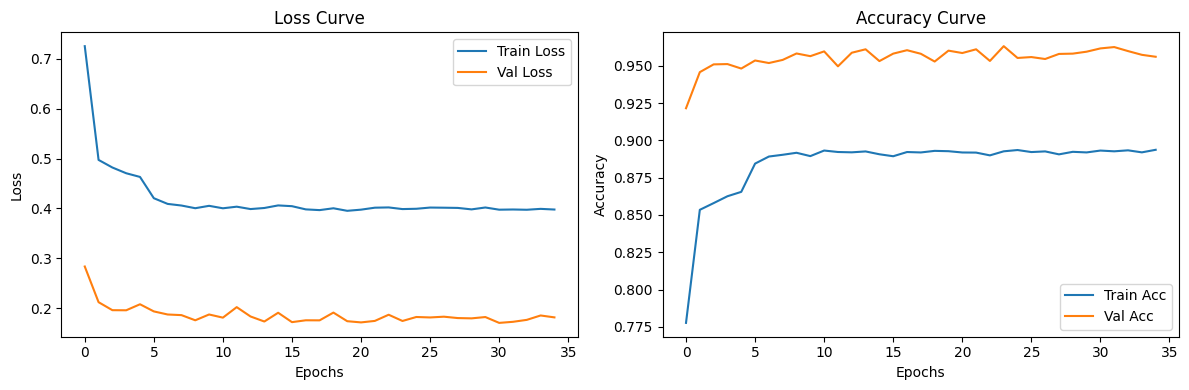

In [12]:
augmentation_config = {
    'if_use_augment' : True,
    'image_shape' : (28, 28), 
    'resize_shape' : (22, 22),
    'translation_prob' : 0.4, 
    'rotation_prob' : 0.4, 
    'resize_prob' : 0.4, 
    'noise_prob' : 0.4,
    'max_shift' : 5, 
    'max_rotation' : 20, 
    'noise_std' : 0.05,
}

mlp_trainer = MLP_train_model(nHidden=[128], augmentation_config=augmentation_config)

#### 若不进行数据增强

best accuracy performence has been updated: 0.00000 --> 0.93920
Epoch 1/100:
[Train] loss: 0.28438, score: 0.91587
[Dev] loss: 0.21094, score: 0.93920
best accuracy performence has been updated: 0.93920 --> 0.95080
Epoch 2/100:
[Train] loss: 0.19305, score: 0.94618
[Dev] loss: 0.18089, score: 0.95080
best accuracy performence has been updated: 0.95080 --> 0.95360
Epoch 3/100:
[Train] loss: 0.18187, score: 0.94972
[Dev] loss: 0.17229, score: 0.95360
Epoch 4/100:
[Train] loss: 0.17628, score: 0.95230
[Dev] loss: 0.17905, score: 0.95260
Epoch 5/100:
[Train] loss: 0.17295, score: 0.95349
[Dev] loss: 0.18781, score: 0.94680
best accuracy performence has been updated: 0.95360 --> 0.95930
Epoch 6/100:
[Train] loss: 0.15758, score: 0.96097
[Dev] loss: 0.16208, score: 0.95930
Epoch 7/100:
[Train] loss: 0.15456, score: 0.96047
[Dev] loss: 0.16122, score: 0.95890
Epoch 8/100:
[Train] loss: 0.15373, score: 0.96143
[Dev] loss: 0.16255, score: 0.95730
Epoch 9/100:
[Train] loss: 0.15310, score: 0.961

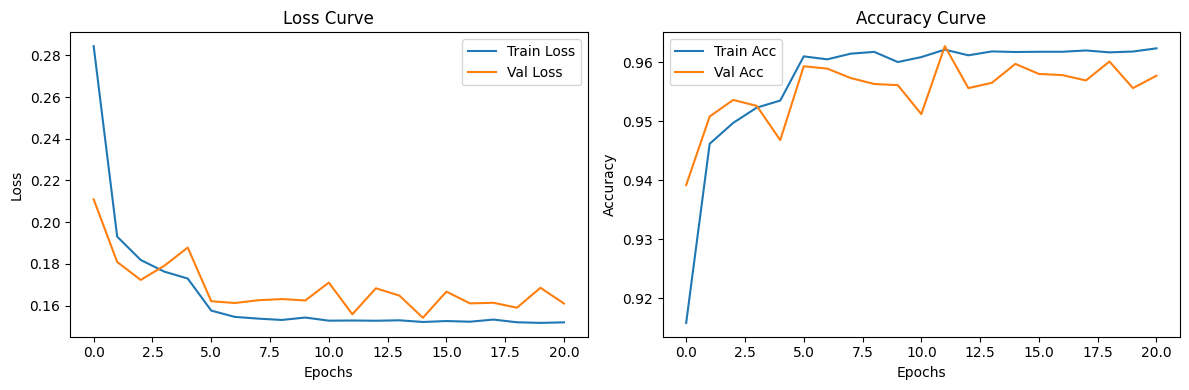

In [9]:
mlp_trainer_noargument = MLP_train_model(nHidden=[128], augmentation_config=None)

### 对CNN进行数据增强

In [3]:
# 在现有预处理基础上增加维度扩展
train_imgs = train_imgs.reshape(-1, 1, 28, 28)  # 转换为[N, C, H, W]格式
valid_imgs = valid_imgs.reshape(-1, 1, 28, 28)

def cnn_train_model(conv_layer_config,fully_connected_config,activation_function, apply_global_avg_pool,lr,epochs,save_dir, early_stop=10, augmentation_config=None):
    # 初始化CNN模型
    model = mynn.models.Model_CNN(
        conv_layer_config = conv_layer_config,
        fully_connected_config = fully_connected_config,
        activation_function = activation_function,
        apply_global_avg_pool = apply_global_avg_pool
    )
    
    opt = mynn.optimizer.MomentGD(init_lr=lr, model=model, mu=0.9)
    scheduler = mynn.lr_scheduler.MultiStepLR(opt, milestones=[8000,50000, 75000], gamma=0.5)
    loss_fn = mynn.op.MultiCrossEntropyLoss(model=model)
    metric = mynn.metric.accuracy
    
    trainer = mynn.runner.RunnerM(
        model=model,
        optimizer=opt,
        metric=metric,
        loss_fn=loss_fn,
        batch_size=64,
        scheduler=scheduler,
        augmentation_config=augmentation_config  # 传递数据增强配置
    )

    trainer.train(
        train_set=(train_imgs, train_labs),
        dev_set=(valid_imgs, valid_labs),
        num_epochs=epochs,
        log_epochs=1,  # 每1个epoch打印一次日志
        save_dir=save_dir,
        early_stop=early_stop  # 传递早停参数
    )


    # 绘制训练曲线
    _, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(trainer.train_loss, label='Train Loss')
    axes[0].plot(trainer.dev_loss, label='Val Loss')
    axes[0].set_title('Loss Curve')
    axes[0].legend()
    
    axes[1].plot(trainer.train_scores, label='Train Acc')
    axes[1].plot(trainer.dev_scores, label='Val Acc')
    axes[1].set_title('Accuracy Curve')
    axes[1].legend()
    
    plt.show()
    
    return trainer

Using data augmentation. The settings:
  image_shape: (28, 28)
  resize_shape: (22, 22)
  translation_prob: 0.4
  rotation_prob: 0.4
  resize_prob: 0.4
  noise_prob: 0.4
  max_shift: 5
  max_rotation: 20
  noise_std: 0.05
best accuracy performence has been updated: 0.00000 --> 0.93920
Epoch 1/100:
[Train] loss: 1.22843, score: 0.62254
[Dev] loss: 0.30634, score: 0.93920
best accuracy performence has been updated: 0.93920 --> 0.95830
Epoch 2/100:
[Train] loss: 0.62325, score: 0.81140
[Dev] loss: 0.18616, score: 0.95830
best accuracy performence has been updated: 0.95830 --> 0.96120
Epoch 3/100:
[Train] loss: 0.46941, score: 0.86095
[Dev] loss: 0.16733, score: 0.96120
best accuracy performence has been updated: 0.96120 --> 0.96400
Epoch 4/100:
[Train] loss: 0.41613, score: 0.87586
[Dev] loss: 0.14302, score: 0.96400
Epoch 5/100:
[Train] loss: 0.38245, score: 0.88669
[Dev] loss: 0.14356, score: 0.96380
Epoch 6/100:
[Train] loss: 0.36256, score: 0.89256
[Dev] loss: 0.14653, score: 0.95880


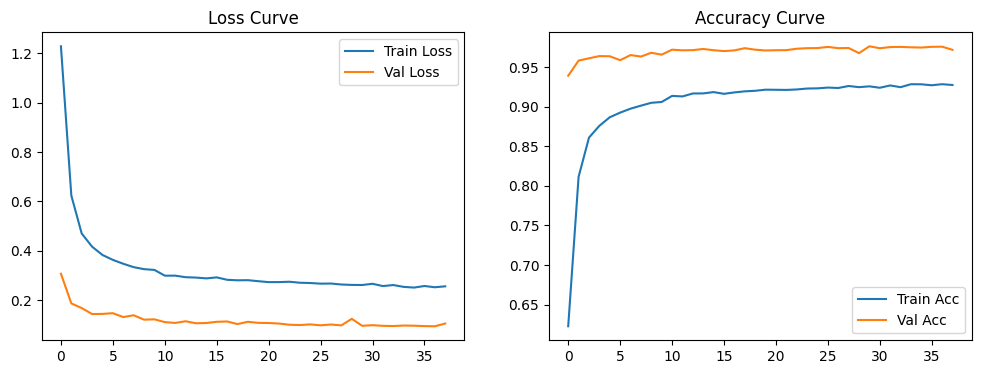

In [ ]:
conv_configs = [   
    {
        'layer_type': 'conv',
        'in_channels': 1,
        'out_channels': 8,     # 减小通道数
        'kernel_size': 3,
        'stride': 1,
        'padding': 1,
        'weight_decay': True,
        'weight_decay_lambda': 1e-4
    },
    {
        'layer_type': 'pool',
        'pooling_type': 'max',   # 从 average 改为 max
        'kernel_size': 2,
        'stride': 2
    },
    {
        'layer_type': 'conv',
        'in_channels': 8,
        'out_channels': 16,
        'kernel_size': 3,
        'stride': 1,
        'padding': 1,
        'weight_decay': True,
        'weight_decay_lambda': 1e-4
    },
    {
        'layer_type': 'pool',
        'pooling_type': 'max',   # 从 average 改为 max
        'kernel_size': 2,
        'stride': 2
    }
]

fc_configs = [
    {"in_dim": 784, "out_dim": 10, "weight_decay": True, "weight_decay_lambda": 1e-4},
]



augmentation_config = {
    'if_use_augment' : True,
    'image_shape' : (28, 28), 
    'resize_shape' : (22, 22),
    'translation_prob' : 0.4, 
    'rotation_prob' : 0.4, 
    'resize_prob' : 0.4, 
    'noise_prob' : 0.4,
    'max_shift' : 5, 
    'max_rotation' : 20, 
    'noise_std' : 0.05,
}

trainer_CNN = cnn_train_model(conv_configs, fc_configs, 'ReLU', False, 0.1, 100, f'./saved_models/Q6/cnn_model_argument', early_stop=7, augmentation_config=augmentation_config) 
         

Using data augmentation. The settings:
  image_shape: (28, 28)
  resize_shape: (22, 22)
  translation_prob: 0.5
  rotation_prob: 0.5
  resize_prob: 0.1
  noise_prob: 0.1
  max_shift: 5
  max_rotation: 20
  noise_std: 0.01
best accuracy performence has been updated: 0.00000 --> 0.91050
Epoch 1/100:
[Train] loss: 1.29707, score: 0.59275
[Dev] loss: 0.35403, score: 0.91050
best accuracy performence has been updated: 0.91050 --> 0.93970
Epoch 2/100:
[Train] loss: 0.65987, score: 0.80065
[Dev] loss: 0.23147, score: 0.93970
best accuracy performence has been updated: 0.93970 --> 0.95820
Epoch 3/100:
[Train] loss: 0.50884, score: 0.84677
[Dev] loss: 0.17029, score: 0.95820
Epoch 4/100:
[Train] loss: 0.43949, score: 0.86841
[Dev] loss: 0.16399, score: 0.95440
Epoch 5/100:
[Train] loss: 0.40568, score: 0.87928
[Dev] loss: 0.15957, score: 0.95630
best accuracy performence has been updated: 0.95820 --> 0.95870
Epoch 6/100:
[Train] loss: 0.38178, score: 0.88713
[Dev] loss: 0.15073, score: 0.95870


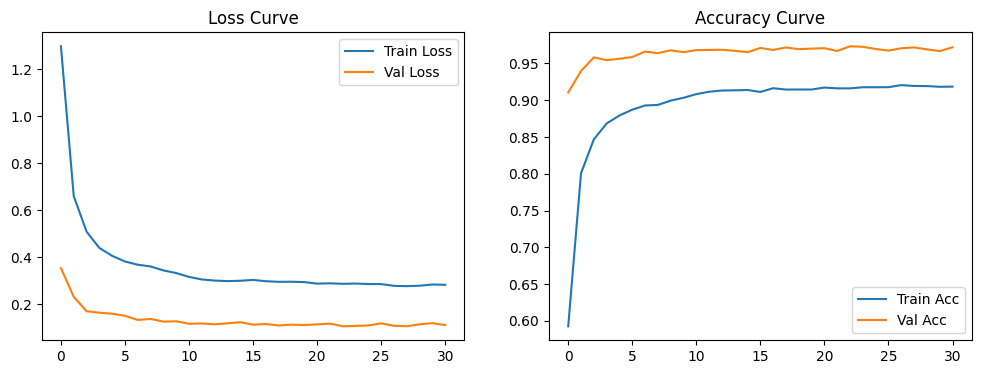

In [ ]:
# trial
conv_configs = [   
    {
        'layer_type': 'conv',
        'in_channels': 1,
        'out_channels': 8,     # 减小通道数
        'kernel_size': 3,
        'stride': 1,
        'padding': 1,
        'weight_decay': True,
        'weight_decay_lambda': 1e-4
    },
    {
        'layer_type': 'pool',
        'pooling_type': 'max',   # 从 average 改为 max
        'kernel_size': 2,
        'stride': 2
    },
    {
        'layer_type': 'conv',
        'in_channels': 8,
        'out_channels': 16,
        'kernel_size': 3,
        'stride': 1,
        'padding': 1,
        'weight_decay': True,
        'weight_decay_lambda': 1e-4
    },
    {
        'layer_type': 'pool',
        'pooling_type': 'max',   # 从 average 改为 max
        'kernel_size': 2,
        'stride': 2
    }
]

fc_configs = [
    {"in_dim": 784, "out_dim": 10, "weight_decay": True, "weight_decay_lambda": 1e-4},
]



augmentation_config = {
    'if_use_augment' : True,
    'image_shape' : (28, 28), 
    'resize_shape' : (22, 22),
    'translation_prob' : 0.5, 
    'rotation_prob' : 0.5, 
    'resize_prob' : 0.1, 
    'noise_prob' : 0.1,
    'max_shift' : 5, 
    'max_rotation' : 20, 
    'noise_std' : 0.01,
}

trainer_CNN = cnn_train_model(conv_configs, fc_configs, 'ReLU', False, 0.1, 100, f'./saved_models/Q6/cnn_model_argument2', early_stop=7, augmentation_config=augmentation_config) 
         

Using data augmentation. The settings:
  image_shape: (28, 28)
  resize_shape: (22, 22)
  translation_prob: 0.3
  rotation_prob: 0.3
  resize_prob: 0.3
  noise_prob: 0.3
  max_shift: 5
  max_rotation: 25
  noise_std: 0.01
best accuracy performence has been updated: 0.00000 --> 0.93120
Epoch 1/100:
[Train] loss: 1.05518, score: 0.67981
[Dev] loss: 0.28851, score: 0.93120
best accuracy performence has been updated: 0.93120 --> 0.95340
Epoch 2/100:
[Train] loss: 0.55617, score: 0.83216
[Dev] loss: 0.19578, score: 0.95340
best accuracy performence has been updated: 0.95340 --> 0.95800
Epoch 3/100:
[Train] loss: 0.43339, score: 0.86992
[Dev] loss: 0.16697, score: 0.95800
best accuracy performence has been updated: 0.95800 --> 0.95980
Epoch 4/100:
[Train] loss: 0.37394, score: 0.88981
[Dev] loss: 0.16276, score: 0.95980
best accuracy performence has been updated: 0.95980 --> 0.96860
Epoch 5/100:
[Train] loss: 0.34519, score: 0.89838
[Dev] loss: 0.13713, score: 0.96860
Epoch 6/100:
[Train] lo

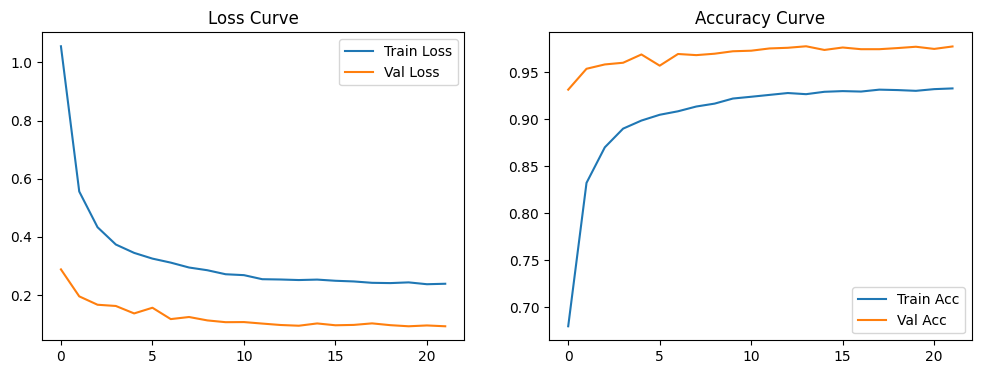

In [7]:
# trial
conv_configs = [   
    {
        'layer_type': 'conv',
        'in_channels': 1,
        'out_channels': 8,     # 减小通道数
        'kernel_size': 3,
        'stride': 1,
        'padding': 1,
        'weight_decay': True,
        'weight_decay_lambda': 1e-4
    },
    {
        'layer_type': 'pool',
        'pooling_type': 'max',   # 从 average 改为 max
        'kernel_size': 2,
        'stride': 2
    },
    {
        'layer_type': 'conv',
        'in_channels': 8,
        'out_channels': 16,
        'kernel_size': 3,
        'stride': 1,
        'padding': 1,
        'weight_decay': True,
        'weight_decay_lambda': 1e-4
    },
    {
        'layer_type': 'pool',
        'pooling_type': 'max',   # 从 average 改为 max
        'kernel_size': 2,
        'stride': 2
    }
]

fc_configs = [
    {"in_dim": 784, "out_dim": 10, "weight_decay": True, "weight_decay_lambda": 1e-4},
]



augmentation_config = {
    'if_use_augment' : True,
    'image_shape' : (28, 28), 
    'resize_shape' : (22, 22),
    'translation_prob' : 0.3, 
    'rotation_prob' : 0.3, 
    'resize_prob' : 0.3, 
    'noise_prob' : 0.3,
    'max_shift' : 5, 
    'max_rotation' : 25, 
    'noise_std' : 0.01,
}

trainer_CNN = cnn_train_model(conv_configs, fc_configs, 'ReLU', False, 0.1, 100, f'./saved_models/Q6/cnn_model_argument3', early_stop=7, augmentation_config=augmentation_config) 
         

Using data augmentation. The settings:
  image_shape: (28, 28)
  resize_shape: (22, 22)
  translation_prob: 0.5
  rotation_prob: 0.0
  resize_prob: 0.0
  noise_prob: 0.0
  max_shift: 5
  max_rotation: 25
  noise_std: 0.01
best accuracy performence has been updated: 0.00000 --> 0.93240
Epoch 1/100:
[Train] loss: 1.13008, score: 0.64626
[Dev] loss: 0.27840, score: 0.93240
best accuracy performence has been updated: 0.93240 --> 0.94600
Epoch 2/100:
[Train] loss: 0.51664, score: 0.84483
[Dev] loss: 0.20559, score: 0.94600
best accuracy performence has been updated: 0.94600 --> 0.94740
Epoch 3/100:
[Train] loss: 0.39927, score: 0.88115
[Dev] loss: 0.18232, score: 0.94740
best accuracy performence has been updated: 0.94740 --> 0.95770
Epoch 4/100:
[Train] loss: 0.35514, score: 0.89476
[Dev] loss: 0.15767, score: 0.95770
Epoch 5/100:
[Train] loss: 0.32785, score: 0.90313
[Dev] loss: 0.15895, score: 0.95160
best accuracy performence has been updated: 0.95770 --> 0.96040
Epoch 6/100:
[Train] lo

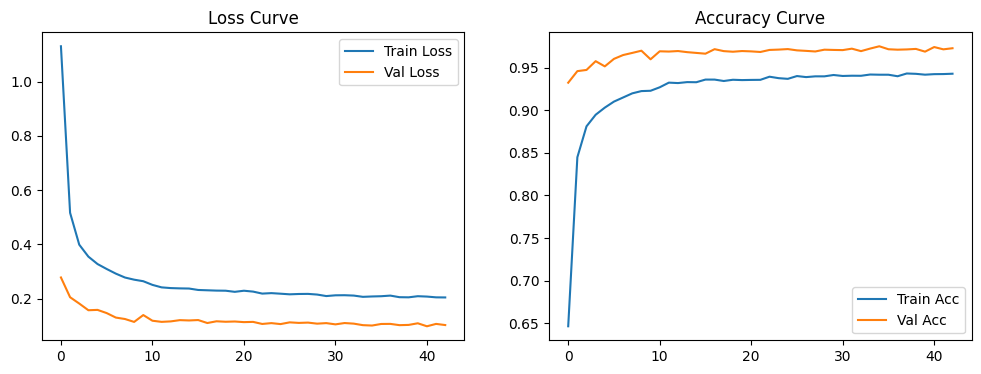

In [8]:
# trial
conv_configs = [   
    {
        'layer_type': 'conv',
        'in_channels': 1,
        'out_channels': 8,     # 减小通道数
        'kernel_size': 3,
        'stride': 1,
        'padding': 1,
        'weight_decay': True,
        'weight_decay_lambda': 1e-4
    },
    {
        'layer_type': 'pool',
        'pooling_type': 'max',   # 从 average 改为 max
        'kernel_size': 2,
        'stride': 2
    },
    {
        'layer_type': 'conv',
        'in_channels': 8,
        'out_channels': 16,
        'kernel_size': 3,
        'stride': 1,
        'padding': 1,
        'weight_decay': True,
        'weight_decay_lambda': 1e-4
    },
    {
        'layer_type': 'pool',
        'pooling_type': 'max',   # 从 average 改为 max
        'kernel_size': 2,
        'stride': 2
    }
]

fc_configs = [
    {"in_dim": 784, "out_dim": 10, "weight_decay": True, "weight_decay_lambda": 1e-4},
]



augmentation_config = {
    'if_use_augment' : True,
    'image_shape' : (28, 28), 
    'resize_shape' : (22, 22),
    'translation_prob' : 0.5, 
    'rotation_prob' : 0.0, 
    'resize_prob' : 0.0, 
    'noise_prob' : 0.0,
    'max_shift' : 5, 
    'max_rotation' : 25, 
    'noise_std' : 0.01,
}

trainer_CNN = cnn_train_model(conv_configs, fc_configs, 'ReLU', False, 0.1, 100, f'./saved_models/Q6/cnn_model_argument5', early_stop=7, augmentation_config=augmentation_config) 
         